# **EDA**

## **1-数据加载**

In [17]:
# ==============================================
# 1. 导入库
# ==============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from wordcloud import WordCloud

# 设置绘图风格
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# ==============================================
# 2. 加载数据
# ==============================================
# 注意：Kaggle 环境中 .tsv.zip 文件通常已经解压，可直接读取 .tsv
train = pd.read_csv('/kaggle/input/competitions/word2vec-nlp-tutorial/labeledTrainData.tsv.zip', 
                    sep='\t', compression='zip')
test = pd.read_csv('/kaggle/input/competitions/word2vec-nlp-tutorial/testData.tsv.zip', 
                   sep='\t', compression='zip')
submission = pd.read_csv('/kaggle/input/competitions/word2vec-nlp-tutorial/sampleSubmission.csv')

print("训练集形状:", train.shape)
print("测试集形状:", test.shape)
print("提交样例形状:", submission.shape)

# 查看前几行
train.head()

训练集形状: (25000, 3)
测试集形状: (25000, 2)
提交样例形状: (25000, 2)


,id,sentiment,review
0,5814_8,1,With all this stuff going down at the moment w...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi..."
2,7759_3,0,The film starts with a manager (Nicholas Bell)...
3,3630_4,0,It must be assumed that those who praised this...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...


**数据字段说明**

id：评论唯一标识

sentiment：情感标签，1 表示正面，0 表示负面

review：评论文本（可能包含 HTML 标签）

## **2-目标变量分布**

/tmp/ipykernel_58/879546298.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=train, palette='viridis')


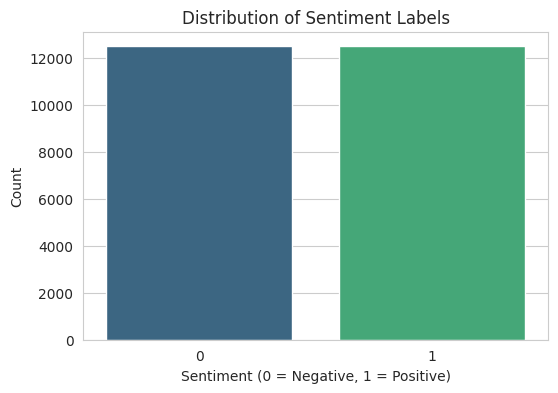

负面评论占比: 50.00%
正面评论占比: 50.00%


In [18]:
# 情感标签分布
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=train, palette='viridis')
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment (0 = Negative, 1 = Positive)')
plt.ylabel('Count')
plt.show()

# 打印比例
sentiment_counts = train['sentiment'].value_counts(normalize=True) * 100
print(f"负面评论占比: {sentiment_counts[0]:.2f}%")
print(f"正面评论占比: {sentiment_counts[1]:.2f}%")

类别完全平衡，不需要做欠采样或过采样

## **3-缺失值检查**

In [19]:
# 检查缺失值
print("训练集缺失值：")
print(train.isnull().sum())
print("\n测试集缺失值：")
print(test.isnull().sum())

训练集缺失值：
id           0
sentiment    0
review       0
dtype: int64

测试集缺失值：
id        0
review    0
dtype: int64


无缺失值，无需填充

## **4-文本长度分析**

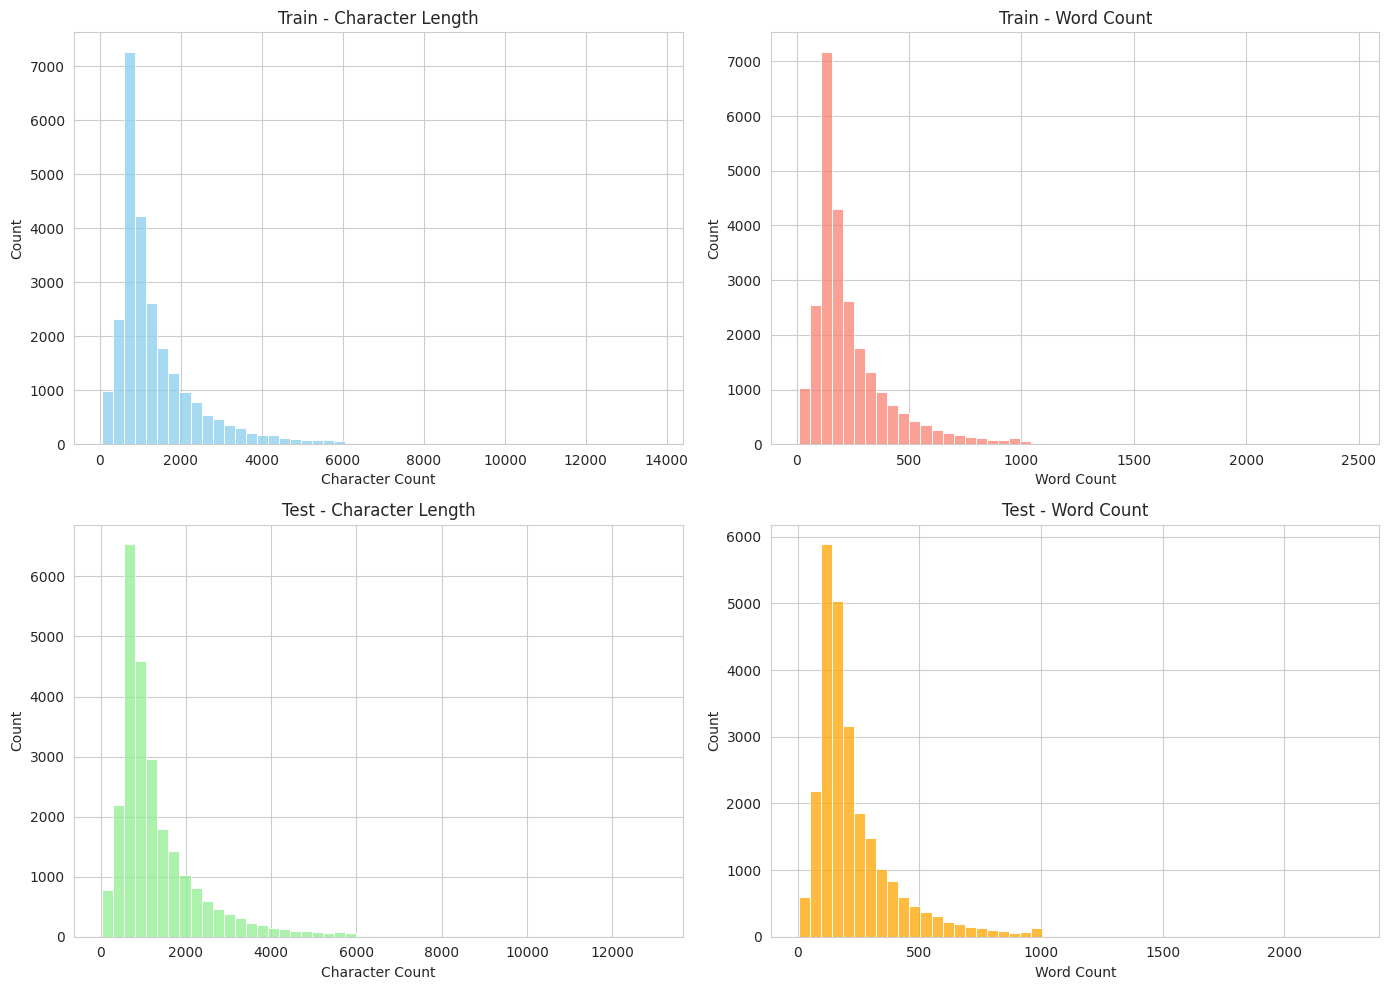

训练集字符数统计：
count    25000.000000
mean      1327.710560
std       1005.239246
min         52.000000
25%        703.000000
50%        981.000000
75%       1617.000000
max      13708.000000
Name: char_length, dtype: float64

训练集单词数统计：
count    25000.000000
mean       233.787640
std        173.733321
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: word_count, dtype: float64

测试集字符数统计：
count    25000.000000
mean      1296.443280
std        978.123328
min         32.000000
25%        697.000000
50%        964.500000
75%       1575.000000
max      13004.000000
Name: char_length, dtype: float64

测试集单词数统计：
count    25000.000000
mean       228.527640
std        168.884543
min          4.000000
25%        126.000000
50%        172.000000
75%        277.000000
max       2278.000000
Name: word_count, dtype: float64


In [20]:
# 计算每条评论的字符数和单词数
train['char_length'] = train['review'].astype(str).apply(len)
train['word_count'] = train['review'].astype(str).apply(lambda x: len(x.split()))

test['char_length'] = test['review'].astype(str).apply(len)
test['word_count'] = test['review'].astype(str).apply(lambda x: len(x.split()))

# 绘制字符长度分布 2行 2列
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(train['char_length'], bins=50, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Train - Character Length')
axes[0,0].set_xlabel('Character Count')

sns.histplot(train['word_count'], bins=50, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Train - Word Count')
axes[0,1].set_xlabel('Word Count')

sns.histplot(test['char_length'], bins=50, ax=axes[1,0], color='lightgreen')
axes[1,0].set_title('Test - Character Length')
axes[1,0].set_xlabel('Character Count')

sns.histplot(test['word_count'], bins=50, ax=axes[1,1], color='orange')
axes[1,1].set_title('Test - Word Count')
axes[1,1].set_xlabel('Word Count')

plt.tight_layout()
plt.show()

# 打印训练集统计信息
print("训练集字符数统计：")
print(train['char_length'].describe())
print("\n训练集单词数统计：")
print(train['word_count'].describe())

# 打印测试集统计信息
print("\n测试集字符数统计：")
print(test['char_length'].describe())
print("\n测试集单词数统计：")
print(test['word_count'].describe())

训练集中平均单词数约 233，中位数 174，但最大可达 2470 词，说明存在一些极长评论

BERT 的默认最大长度为 512 token（单词大致对应 token），因此很多评论会被截断。后续需要决定截断策略（如取前 256/512，或采用滑窗平均）

## **5-异常符号检查**

In [21]:
# 检查是否包含 HTML 标签（简单正则）
html_pattern = re.compile(r'<[^>]+>')
train['has_html'] = train['review'].apply(lambda x: bool(html_pattern.search(x)))
html_ratio = train['has_html'].mean() * 100
print(f"包含 HTML 标签的评论占比: {html_ratio:.2f}%")

# 展示一条包含 HTML 的评论
sample_html = train[train['has_html']]['review'].iloc[0]
print("\n示例:")
print(sample_html[:])

包含 HTML 标签的评论占比: 58.67%

示例:
With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature 

58.67%的评论包含 HTML 标签，需要在预处理时去除，否则会干扰模型

##  **6-正负面评论词频分析**

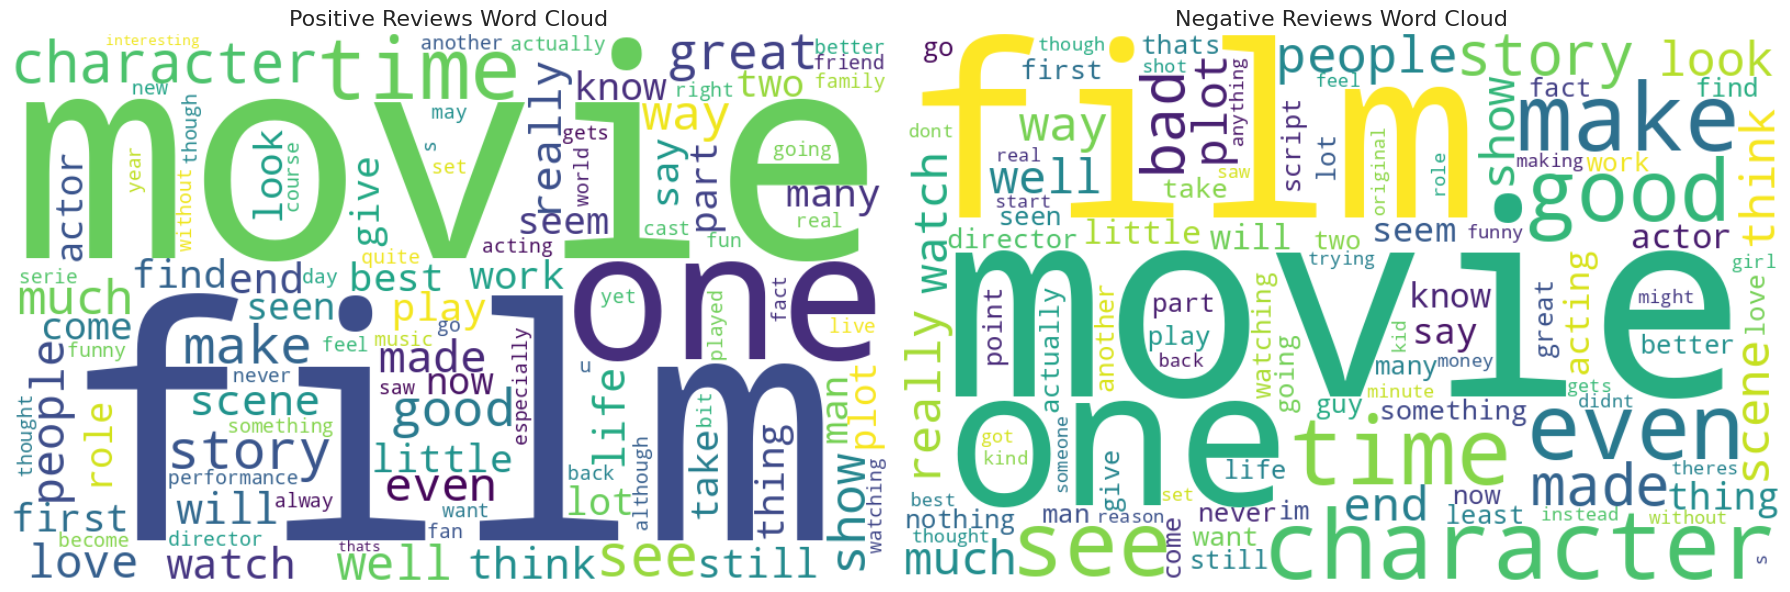

/tmp/ipykernel_58/971854333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentiment', y='word_count', data=train, palette='Set2')


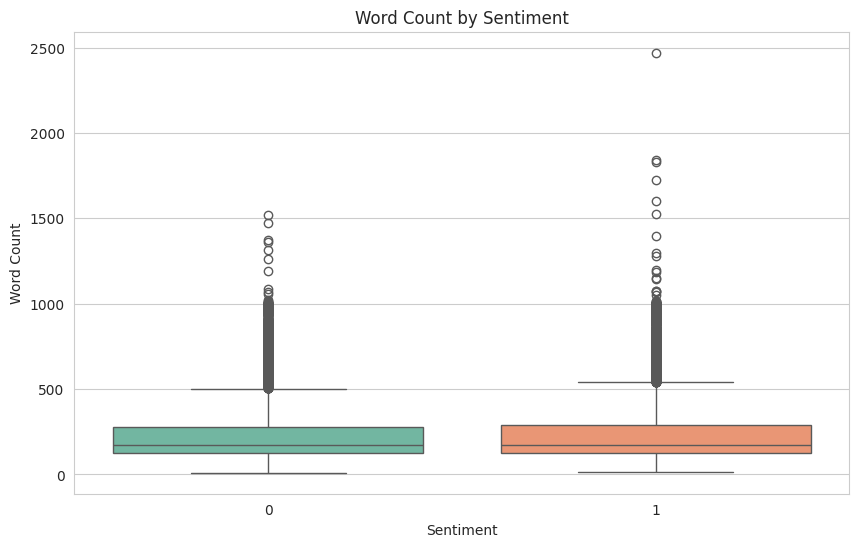

In [22]:
# 将 HTML 标签替换为空格，然后合并文本
def clean_for_wordcloud(text):
    text = re.sub(r'<[^>]+>', ' ', text)  # 去除 HTML 标签
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # 只保留字母
    return text.lower()

train['clean_review'] = train['review'].apply(clean_for_wordcloud)

# 分离正负面评论
positive_text = ' '.join(train[train['sentiment']==1]['clean_review'].tolist())
negative_text = ' '.join(train[train['sentiment']==0]['clean_review'].tolist())

# 生成词云
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
wc_pos = WordCloud(width=800, height=500, background_color='white', max_words=100).generate(positive_text)
wc_neg = WordCloud(width=800, height=500, background_color='white', max_words=100).generate(negative_text)

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews Word Cloud', fontsize=16)
axes[0].axis('off')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews Word Cloud', fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()


# 正负面评论长度对比
plt.figure(figsize=(10,6))
sns.boxplot(x='sentiment', y='word_count', data=train, palette='Set2')
plt.title('Word Count by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Word Count')
plt.show()

* 正负评论中占据较大比重的词汇都是 “movie”、“film”、“time”、“character” 这样的电影评价共性词，二者从词云图看不出明显差别，想要通过个别词汇作为特征或验证模型的方向还需要进一步考虑

* 从评论长度来看，两类评论的长度分布相似，正面评论极端情况略长一些，但差异不大

## **7-EDA总结**

通过以上分析，我们得到以下关键信息：

数据规模：训练 25,000 条，测试 25,000 条，无缺失值。

类别平衡：正负面各 50%，无需处理不平衡。

文本长度：平均 233 词，但分布范围广，存在长尾。对于 BERT 需要设置合适的 MAX_LEN 或采用截断策略。

HTML 标签：58.67% 评论包含 HTML 标签，必须在预处理时清理。

高频词：词云图展示出正负面评论的高频词无明显差异

# **Baseline：TF-IDF + Logistic Regression**

* 文本清洗：去除 HTML 标签、标点、数字（保留字母数字），转为小写。对于情感分析，保留数字可能有用，但 baseline 简单处理。

* TF-IDF：使用 unigram+bigram，去除英文停用词，sublinear_tf=True 将词频缩放为 1+log(tf)，通常能提升线性模型的效果。

* 模型：逻辑回归配合 saga 求解器，适合高维稀疏特征。正则化参数 C=1.0 是默认值，可通过交叉验证微调。

* 评估：采用 5 折分层交叉验证计算 AUC，得到约 0.95 的分数。

* 预测：输出测试集正类概率，直接生成符合竞赛要求的提交文件（AUC 评价只需概率，无需设定阈值）

In [23]:
# # ==============================================
# # Baseline: TF-IDF + Logistic Regression
# # 任务：IMDB 电影评论情感分类（二分类，评价指标 AUC）
# # 环境：CPU 即可运行（无需 GPU）
# # ==============================================

# import pandas as pd
# import numpy as np
# import re
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import cross_val_score, StratifiedKFold
# from sklearn.metrics import roc_auc_score

# # EDA 中已加载过数据
# # train = pd.read_csv('/kaggle/input/competitions/word2vec-nlp-tutorial/labeledTrainData.tsv.zip', 
# #                     sep='\t', compression='zip')
# # test = pd.read_csv('/kaggle/input/competitions/word2vec-nlp-tutorial/testData.tsv.zip', 
# #                    sep='\t', compression='zip')
# # submission = pd.read_csv('/kaggle/input/competitions/word2vec-nlp-tutorial/sampleSubmission.csv')


# # ==============================================
# # 1. 文本清洗函数
# # ==============================================
# def clean_text(text):
#     """
#     清洗评论文本：
#     - 去除 HTML 标签（如 <br />）
#     - 保留字母、数字和空格（可根据需要保留标点，但 baseline 选择简化）
#     - 转为小写
#     """
#     if not isinstance(text, str):
#         text = ""
#     # 移除 HTML 标签
#     text = re.sub(r'<[^>]+>', ' ', text)
#     # 只保留字母、数字和空格（去除标点）
#     text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
#     # 合并多个空格并去除首尾空格
#     text = re.sub(r'\s+', ' ', text).strip()
#     # 转为小写
#     text = text.lower()
#     return text

# # 应用清洗到训练集和测试集
# print("正在清洗文本...")
# train['clean_review'] = train['review'].apply(clean_text)
# test['clean_review'] = test['review'].apply(clean_text)

# # 预览清洗后的文本
# print("清洗后训练集前2条：")
# print(train['clean_review'].head(2))

# # ==============================================
# # 2. TF-IDF 特征提取
# # ==============================================
# # 使用单词和二元词组，限制最大特征数以防止过拟合和降低内存占用
# # 由于评论文本较长，可以适当提高 max_features，这里取 50000（在 CPU 上仍可处理）
# tfidf = TfidfVectorizer(
#     max_features=50000,      # 最大特征数
#     ngram_range=(1, 2),      # 使用 unigram 和 bigram
#     stop_words='english',    # 移除英文停用词
#     sublinear_tf=True        # 使用 1+log(tf) 缩放，通常能提升性能
# )

# print("正在提取 TF-IDF 特征...")
# X_train = tfidf.fit_transform(train['clean_review'])
# X_test = tfidf.transform(test['clean_review'])
# y_train = train['sentiment'].values

# print(f"TF-IDF 训练集维度: {X_train.shape}")
# print(f"TF-IDF 测试集维度: {X_test.shape}")

# # ==============================================
# # 3. 模型训练（带交叉验证评估）
# # ==============================================
# # 使用逻辑回归，liblinear 适合小规模数据，lbfgs 适合较大数据
# # 由于特征数较多（50000），使用 saga 求解器支持 L1 或 L2 且适合稀疏数据
# model = LogisticRegression(
#     C=1.0,                 # 正则化强度的倒数，越小正则化越强
#     solver='saga',         # saga 支持 L1/L2 且处理稀疏数据较快
#     max_iter=1000,         # 最大迭代次数
#     random_state=42,
#     n_jobs=-1              # 使用所有 CPU 核心
# )

# # 使用 5 折分层交叉验证评估 AUC
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# print("正在进行交叉验证...")
# cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
# print(f"交叉验证 AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# # ==============================================
# # 4. 在全部训练数据上重新训练
# # ==============================================
# print("在全量训练数据上训练最终模型...")
# model.fit(X_train, y_train)

# # ==============================================
# # 5. 预测测试集概率并生成提交文件
# # ==============================================
# print("预测测试集概率...")
# test_probs = model.predict_proba(X_test)[:, 1]  # 取正类（sentiment=1）的概率

# # 填充提交文件
# submission['sentiment'] = test_probs
# # 检查提交文件格式：id, sentiment (概率)
# print(submission.head())

# # 保存提交文件
# submission.to_csv('submission.csv', index=False)
# print("提交文件已保存为 submission.csv")

# **BERT 微调**

## **1-文本清洗**

In [24]:
# ==============================================
# BERT 微调 - 第一步：数据准备与轻度清洗
# ==============================================

import pandas as pd
import numpy as np
import re
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer

# EDA时数据已加载

# 轻度清洗：只去除 HTML 标签，保留其他所有字符（包括标点、大小写）
def clean_text_bert(text):
    if not isinstance(text, str):
        text = ""
    # 去除 HTML 标签
    text = re.sub(r'<[^>]+>', ' ', text)
    # 合并多个空格，去除首尾空格
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 应用清洗
train['clean_review_bert'] = train['review'].apply(clean_text_bert)
test['clean_review_bert'] = test['review'].apply(clean_text_bert)

# 查看清洗后的一条示例
print(train['clean_review_bert'].iloc[0][:200])

With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want t


## **2-BERT-Dataset 构建**

加载 BERT 的 tokenizer，并创建一个 PyTorch Dataset 类，将**文本**转换为**向量**（即模型所需的 input_ids、attention_mask 和 label）

In [25]:
# ==============================================
# 第二步：Tokenizer 与 Dataset 构建（含训练、验证、测试集）
# ==============================================

# 选择预训练模型（这里使用 bert-base-uncased，也可尝试 distilbert 以加速）
MODEL_NAME = 'bert-base-uncased'
# 加载 tokenizer
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# 设定最大序列长度
# 由于评论文本较长，但 BERT 最大支持 512，我们这里使用 256 或 512
# 考虑到 GPU 内存和训练速度，可以先使用 256，后续可调整
MAX_LEN = 256

class ReviewDataset(Dataset):
    """
    PyTorch Dataset 用于封装评论文本和标签，并转换为模型输入格式。
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # 使用 tokenizer 对文本进行编码
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,      # 添加 [CLS] 和 [SEP]
            max_length=self.max_len,      # 最大长度
            padding='max_length',         # 填充到 max_length
            truncation=True,              # 超长截断
            return_attention_mask=True,   # 返回注意力掩码
            return_tensors='pt'           # 返回 PyTorch 张量
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),          # 形状 (max_len,)
            'attention_mask': encoding['attention_mask'].flatten(), # 形状 (max_len,)
            'labels': torch.tensor(label, dtype=torch.long)         # 标量标签
        }

# 划分训练集和验证集（使用 sklearn 的 train_test_split）
from sklearn.model_selection import train_test_split

X = train['clean_review_bert'].values  # 清洗后的评论文本
y = train['sentiment'].values          # 情感标签

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y  # 分层抽样，保持类别比例
)

# 创建训练集和验证集的 Dataset 实例
train_dataset = ReviewDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset = ReviewDataset(X_val, y_val, tokenizer, MAX_LEN)


# 获取测试集文本（已在前面的数据清洗步骤中生成 clean_review_bert 列）
test_texts = test['clean_review_bert'].values
# 测试集没有真实标签，因此使用全 0 作为占位标签（不会用于计算损失）
test_dataset = ReviewDataset(test_texts, [0]*len(test_texts), tokenizer, MAX_LEN)

# 创建 DataLoader
BATCH_SIZE = 64          # 训练/验证批次大小（可根据 GPU 内存调整）
BATCH_SIZE_TEST = 64     # 测试批次大小可以稍大，加速推理

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE_TEST, shuffle=False)

# 打印数据集信息
print(f"训练集样本数: {len(train_dataset)}")
print(f"验证集样本数: {len(val_dataset)}")
print(f"测试集样本数: {len(test_dataset)}")
print(f"训练 batch 数: {len(train_loader)}")
print(f"测试 batch 数: {len(test_loader)}")

训练集样本数: 22500
验证集样本数: 2500
测试集样本数: 25000
训练 batch 数: 352
测试 batch 数: 391


## **3-模型加载**

使用 HuggingFace 的 BertForSequenceClassification 加载预训练模型，并添加二分类头。同时配置优化器和学习率调度器，为训练做准备

In [26]:
# ==============================================
# 第三步：加载 BERT 模型与优化器配置
# ==============================================

import torch.nn as nn
from transformers import BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

# 检测可用的 GPU 数量
num_gpus = torch.cuda.device_count()
print(f"可用 GPU 数量: {num_gpus}")

# 选择设备（如果有 GPU 则使用 cuda，否则 cpu）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 加载预训练 BERT 模型，指定二分类任务
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,                 # 输出类别数：0 和 1
    output_attentions=False,      # 不需要输出注意力权重
    output_hidden_states=False    # 不需要输出隐藏状态
)

# 如果有多块 GPU，使用 DataParallel 进行并行训练
if num_gpus > 1:
    print(f"使用 {num_gpus} 块 GPU 并行训练（DataParallel）")
    model = nn.DataParallel(model)

# 将模型移动到设备
model.to(device)

# 设置优化器参数
LEARNING_RATE = 2e-5    # 学习率，BERT 微调常用 1e-5 ~ 5e-5，batchsize越大学习率越大
EPOCHS = 3              # 训练轮数，通常 2~4 即可
WARMUP_RATIO = 0.1      # 学习率预热的步数比例

# 使用 PyTorch 自带的 AdamW 优化器（注意不要从 transformers 导入）
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

# 计算总训练步数（用于学习率调度）
total_steps = len(train_loader) * EPOCHS
# 预热步数：前 10% 的步数线性增加学习率
warmup_steps = int(total_steps * WARMUP_RATIO)

# 创建学习率调度器：线性预热 + 线性衰减
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"总训练步数: {total_steps}，预热步数: {warmup_steps}")

可用 GPU 数量: 2
使用设备: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


使用 2 块 GPU 并行训练（DataParallel）
总训练步数: 1056，预热步数: 105


## **4-定义训练与评估函数**

训练函数需要处理损失计算、反向传播、梯度裁剪和参数更新。评估函数则计算验证集上的准确率和 AUC

In [27]:
# ==============================================
# 第四步：训练与评估函数
# ==============================================

from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm   # 导入 tqdm

def train_epoch(model, data_loader, optimizer, scheduler, device):
    """
    训练一个 epoch。
    返回训练集平均损失和准确率。
    """
    model.train()                # 切换到训练模式（启用 dropout 等）
    total_loss = 0               # 累计损失
    correct_predictions = 0      # 正确预测数
    total_predictions = 0        # 总样本数

    # 用 tqdm 包裹 data_loader，显示进度条
    progress_bar = tqdm(data_loader, desc='Training', leave=False)

    for batch in progress_bar:
        # 将数据移动到设备
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # 清空梯度
        optimizer.zero_grad()

        # 前向传播（传入 labels 会自动计算损失）
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        # 多 GPU 训练时，loss 可能是向量，需要取平均
        if loss.dim() > 0:
            loss = loss.mean()

        # 反向传播
        loss.backward()

        # 梯度裁剪，防止梯度爆炸
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # 更新参数
        optimizer.step()
        # 更新学习率
        scheduler.step()

        # 统计
        total_loss += loss.item()
        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == labels).item()
        total_predictions += labels.size(0)

        # 更新进度条显示的当前损失
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(data_loader)
    accuracy = correct_predictions / total_predictions
    return accuracy, avg_loss


def eval_model(model, data_loader, device):
    """
    在验证集上评估模型。
    返回平均损失、准确率和 AUC。
    """
    model.eval()                 # 切换到评估模式（关闭 dropout 等）
    total_loss = 0
    correct_predictions = 0
    total_predictions = 0
    all_probs = []               # 存储正类概率
    all_labels = []              # 存储真实标签

    # 用 tqdm 包裹 data_loader，显示进度条
    progress_bar = tqdm(data_loader, desc='Evaluating', leave=False)

    with torch.no_grad():        # 关闭梯度计算
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            if loss.dim() > 0:
                loss = loss.mean()

            total_loss += loss.item()
            _, preds = torch.max(logits, dim=1)
            correct_predictions += torch.sum(preds == labels).item()
            total_predictions += labels.size(0)

            # 获取正类概率
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # 更新进度条显示的当前损失
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(data_loader)
    accuracy = correct_predictions / total_predictions
    auc = roc_auc_score(all_labels, all_probs)
    return avg_loss, accuracy, auc

## **5-模型训练**

训练中包含早停机制和最佳模型保存

In [29]:
# ==============================================
# 第五步：训练循环（含早停）
# ==============================================

# 初始化最佳验证 AUC 和早停计数器
best_val_auc = 0
patience = 1               # 允许连续没有提升的 epoch 数
early_stop_counter = 0

for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{EPOCHS} ---")

    # 训练
    train_acc, train_loss = train_epoch(
        model, train_loader, optimizer, scheduler, device
    )

    # 验证
    val_loss, val_acc, val_auc = eval_model(model, val_loader, device)

    print(f"训练损失: {train_loss:.4f}, 训练准确率: {train_acc:.4f}")
    print(f"验证损失: {val_loss:.4f}, 验证准确率: {val_acc:.4f}, 验证 AUC: {val_auc:.4f}")

    # 判断是否最佳
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        early_stop_counter = 0

        # 保存最佳模型（注意多 GPU 时需访问 model.module）
        if isinstance(model, nn.DataParallel):
            torch.save(model.module.state_dict(), 'best_model_state.bin')
        else:
            torch.save(model.state_dict(), 'best_model_state.bin')
        print("  -> 保存当前最佳模型")
    else:
        early_stop_counter += 1
        print(f"  -> 验证 AUC 无提升，早停计数: {early_stop_counter}/{patience}")
        if early_stop_counter >= patience:
            print("触发早停，停止训练。")
            break

print(f"\n训练结束，最佳验证 AUC: {best_val_auc:.4f}")


--- Epoch 1/3 ---


Training:   0%|          | 0/352 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

训练损失: 0.3404, 训练准确率: 0.8469
验证损失: 0.2217, 验证准确率: 0.9092, 验证 AUC: 0.9700
  -> 保存当前最佳模型

--- Epoch 2/3 ---


...

训练损失: 0.1711, 训练准确率: 0.9368
验证损失: 0.2137, 验证准确率: 0.9204, 验证 AUC: 0.9739
  -> 保存当前最佳模型

--- Epoch 3/3 ---


Training:   0%|          | 0/352 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

训练损失: 0.1044, 训练准确率: 0.9646
验证损失: 0.2440, 验证准确率: 0.9192, 验证 AUC: 0.9739
  -> 验证 AUC 无提升，早停计数: 1/1
触发早停，停止训练。

训练结束，最佳验证 AUC: 0.9739


## **6-加载最佳模型并预测测试集**

In [30]:
# ==============================================
# 第六步：加载最佳模型并预测测试集
# ==============================================

import torch
import numpy as np
import pandas as pd

# 重新创建模型实例（不使用 DataParallel）
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# 加载保存的最佳权重（已去除 module 前缀）
model.load_state_dict(torch.load('best_model_state.bin'))

# 设备设置（单卡推理即可）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

print("最佳模型加载完成，开始预测...")

# 定义预测函数（只返回正类概率）
def predict_probs(model, data_loader, device):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=1)[:, 1]  # 正面评论概率
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_probs)

# 获取测试集预测概率
test_probs = predict_probs(model, test_loader, device)

# 生成提交文件
submission = pd.read_csv('/kaggle/input/competitions/word2vec-nlp-tutorial/sampleSubmission.csv')  # 请确认路径
submission['sentiment'] = test_probs

# 保存（默认提交概率，AUC 评价下更合理）
submission.to_csv('submission.csv', index=False)
print("提交文件已保存为 submission.csv")
print(submission.head())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


最佳模型加载完成，开始预测...
提交文件已保存为 submission.csv
         id  sentiment
0  12311_10   0.996775
1    8348_2   0.017727
2    5828_4   0.547237
3    7186_2   0.007823
4   12128_7   0.987245
